<a href="https://colab.research.google.com/github/m-zaniolo/CEE690-ESAA/blob/main/Lab04_MPC_OpenLoop_Deterministic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 4 — Model Predictive Control for Lake Operations (deterministic open-loop)

This notebook implements **deterministic MPC** for daily lake releases.  
At each day, we solve a **finite-horizon open-loop** optimization problem, apply the first release, and repeat.

We compare:
- **Climatology forecast** (deterministic mean day-of-year inflow)
- **Perfect forecast** (uses the realized future inflow record)

We also compare:
- lead time **N = 7** vs **N = 30**
- terminal cost **0** vs **H(s)** from the SDP lab (interpolated)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import minimize

## Load data

In [2]:
# Data location (raw GitHub URLs work in Colab)
DATA_URL = "https://raw.githubusercontent.com/m-zaniolo/CEE690-ESAA/main/data/"

# Daily inflow time series [m3/s]
inflow = np.loadtxt(DATA_URL + "inflow.txt", delimiter="\t")

# Cyclostationary net evaporation series [mm/day] (length 365)
evap_mm_day = np.loadtxt(DATA_URL + "netevap_Gibe1.txt", delimiter=" ")

print("inflow length:", len(inflow))
print("evap_mm_day length:", len(evap_mm_day))

inflow length: 5475
evap_mm_day length: 365


## Reservoir model (Lab 1 simulator)

In [3]:
# Reservoir parameters (same as Lab 1 / SDP lab)
S_max = 1.47e10           # [m3] maximum storage
sim_step = 60 * 60 * 24   # [s] one day
stor_to_surface = 0.0142  # [m2/m3] surface = stor_to_surface * storage

def mass_balance_gibeIII(s0, inflow, release, evap_mm_day, S):
    """Lab 1 simulator (daily). Returns storage and level time series."""
    inflow_ = np.concatenate(([-999.0], np.asarray(inflow)))
    release_ = np.concatenate(([-999.0], np.asarray(release)))

    s = np.zeros(len(inflow_), dtype=float)
    s[0] = float(s0)

    H = len(inflow)
    for t in range(H):
        surface = s[t] * stor_to_surface  # [m2]
        evaporation_t = (evap_mm_day[t % 365] / 1000.0) / sim_step * surface  # [m3/s]
        s[t + 1] = s[t] + (inflow_[t + 1] - release_[t + 1] - evaporation_t) * sim_step
        s[t + 1] = min(max(0.0, s[t + 1]), S)

    s = np.asarray(s)
    l = 0.0521 * (s ** 0.3589)
    return s, l

## Step costs and scalar objective (same as SDP lab)

In [4]:
# Objectives (same definitions as SDP lab)
D = 450.0           # [m3/s] agricultural demand
efficiency = 0.9
g = 9.81
d = 1000.0         # density [kg/m3]

# Release capacity (upper bound)
r_max = 1200.0     # [m3/s]

def step_cost_components(level, release):
    """Return hp1 and food step costs for arrays (vectorized)."""
    level = np.asarray(level, dtype=float)
    release = np.asarray(release, dtype=float)

    hp1 = level * release * efficiency * g * d / 10e6
    food = (np.maximum(D - release, 0.0)) ** 2
    return hp1, food

def scalar_step_cost(hp1, food, lam):
    """Scalar step cost to MINIMIZE: lam*food - (1-lam)*hp1."""
    return lam * food - (1.0 - lam) * hp1

## 1) Climatology inflow forecast (deterministic)

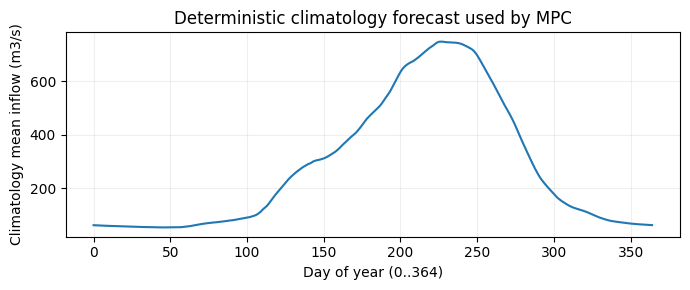

In [5]:
def estimate_climatology_mean(q_series, window=15):
    """Day-of-year climatology mean using a +/- window (in days)."""
    q = np.asarray(q_series, dtype=float)
    q = q[np.isfinite(q)]
    T = len(q)

    doy = np.arange(T) % 365
    q_mean = np.zeros(365, dtype=float)

    for d0 in range(365):
        dist = np.abs(doy - d0)
        dist = np.minimum(dist, 365 - dist)  # circular
        mask = dist <= window
        q_mean[d0] = float(np.mean(q[mask])) if np.any(mask) else float(np.mean(q))

    return q_mean

q_clim = estimate_climatology_mean(inflow, window=15)

plt.figure(figsize=(7,3))
plt.plot(q_clim)
plt.xlabel("Day of year (0..364)")
plt.ylabel("Climatology mean inflow (m3/s)")
plt.title("Deterministic climatology forecast used by MPC")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## MPC core: deterministic open-loop optimization

In [9]:
def solve_open_loop_deterministic(
    s0,
    q_forecast,
    evap_forecast_mm_day,
    lam=0.5,
    gamma=1,
    terminal_mode="zero",
    H_sdp=None,
    s_grid_sdp=None,
    maxiter=60,
    x0=None,
):
    """Solve a deterministic N-day open-loop problem via nonlinear optimization.

    Decision variables: r[0..N-1] (release setpoints), with bounds [0, r_max].
    Feasibility is enforced inside the rollout: r_applied <= s / sim_step.

    terminal_mode:
      - 'zero': terminal cost = 0
      - 'Hsdp': terminal cost = gamma^N * H_sdp(s_N), with interpolation
    """
    q_forecast = np.asarray(q_forecast, dtype=float)
    N = len(q_forecast)
    evap_forecast_mm_day = np.asarray(evap_forecast_mm_day, dtype=float)

    if x0 is None:
        x0 = np.full(N, D, dtype=float)
    else:
        x0 = np.asarray(x0, dtype=float).copy()
        if len(x0) != N:
            x0 = np.full(N, D, dtype=float)

    bounds = [(0.0, r_max)] * N

    def rollout_objective(r_plan):
        s = float(s0)
        J = 0.0

        for k in range(N):
            # applied release (feasible)
            r_applied = min(float(r_plan[k]), r_max, s / sim_step)

            # level from current storage (Lab 1 curve)
            l_now = 0.0521 * (s ** 0.3589)

            # step costs
            hp1_k, food_k = step_cost_components(l_now, r_applied)
            J += (gamma ** k) * float(scalar_step_cost(hp1_k, food_k, lam))

            # one-step storage update (same as Lab 1 loop)
            surface = s * stor_to_surface
            evaporation_k = (float(evap_forecast_mm_day[k]) / 1000.0) / sim_step * surface  # [m3/s]
            s = s + (float(q_forecast[k]) - r_applied - evaporation_k) * sim_step
            s = float(np.clip(s, 0.0, S_max))

        # terminal penalty
        if terminal_mode == "Hsdp":
            if (H_sdp is None) or (s_grid_sdp is None):
                raise ValueError("terminal_mode='Hsdp' requires H_sdp and s_grid_sdp.")
            H_end = float(np.interp(s, s_grid_sdp, H_sdp))
            J += (gamma ** N) * H_end

        return J

    res = minimize(
        rollout_objective,
        x0,
        method="L-BFGS-B",
        bounds=bounds,
        options={"maxiter": int(maxiter)},
    )

    r_star = np.asarray(res.x, dtype=float)

    # Return also the *applied* plan under feasibility
    s = float(s0)
    r_applied_plan = np.zeros_like(r_star)
    for k in range(N):
        r_applied_plan[k] = min(float(r_star[k]), r_max, s / sim_step)
        surface = s * stor_to_surface
        evaporation_k = (float(evap_forecast_mm_day[k]) / 1000.0) / sim_step * surface
        s = s + (float(q_forecast[k]) - r_applied_plan[k] - evaporation_k) * sim_step
        s = float(np.clip(s, 0.0, S_max))

    return r_applied_plan, res

## MPC simulation over 1 year (receding horizon)

In [10]:
def simulate_mpc_one_year(
    start_index,
    N,
    lam,
    gamma,
    forecast_mode,
    q_clim,
    terminal_mode="zero",
    H_sdp=None,
    s_grid_sdp=None,
    maxiter=60,
):
    """Simulate 365 days with receding-horizon MPC.

    forecast_mode:
      - 'clim': deterministic climatology mean forecast
      - 'perfect': uses the realized inflow record as forecast
    """
    H_sim = 365
    inflow_full = np.asarray(inflow, dtype=float)

    inflow_true = inflow_full[start_index : start_index + H_sim]
    if len(inflow_true) < H_sim:
        raise ValueError("Not enough inflow data for a 1-year simulation at this start_index.")

    release = np.zeros(H_sim, dtype=float)

    # internal storage tracker for constraints and forecast updates
    s = 0.7 * S_max
    r_init = None  # warm start

    for t in range(H_sim):
        # Build deterministic forecast trajectory q_fore[0..N-1]
        q_fore = np.zeros(N, dtype=float)
        e_fore = np.zeros(N, dtype=float)

        for k in range(N):
            e_fore[k] = float(evap_mm_day[(t + k) % 365])

            if forecast_mode == "clim":
                q_fore[k] = float(q_clim[(t + k) % 365])
            elif forecast_mode == "perfect":
                idx = start_index + t + k
                if idx < len(inflow_full):
                    q_fore[k] = float(inflow_full[idx])
                else:
                    # pad with climatology if we run out of record
                    q_fore[k] = float(q_clim[(t + k) % 365])
            else:
                raise ValueError("forecast_mode must be 'clim' or 'perfect'.")

        # Warm start: shift yesterday's plan
        if r_init is not None:
            r_init = np.concatenate([r_init[1:], [r_init[-1]]])
        else:
            r_init = np.full(N, D, dtype=float)

        r_plan, _ = solve_open_loop_deterministic(
            s0=s,
            q_forecast=q_fore,
            evap_forecast_mm_day=e_fore,
            lam=lam,
            gamma=gamma,
            terminal_mode=terminal_mode,
            H_sdp=H_sdp,
            s_grid_sdp=s_grid_sdp,
            maxiter=maxiter,
            x0=r_init,
        )

        # Apply first release
        r0 = float(r_plan[0])
        release[t] = r0

        # Update internal storage using the realized inflow at day t (same as Lab 1)
        surface = s * stor_to_surface
        evaporation_t = (float(evap_mm_day[t % 365]) / 1000.0) / sim_step * surface
        s = s + (float(inflow_true[t]) - r0 - evaporation_t) * sim_step
        s = float(np.clip(s, 0.0, S_max))

        # Save for warm-start
        r_init = r_plan

    # Re-simulate with Lab 1 function for reporting (storage + level)
    s_ts, l_ts = mass_balance_gibeIII(0.7 * S_max, inflow_true, release, evap_mm_day, S_max)

    # Step costs on decision days using level at time t
    hp1, food = step_cost_components(l_ts[:-1], release)
    J = scalar_step_cost(hp1, food, lam)

    return {
        "inflow_true": inflow_true,
        "release": release,
        "storage": s_ts,
        "level": l_ts,
        "mean_hp1": float(np.mean(hp1)),
        "mean_food": float(np.mean(food)),
        "mean_J": float(np.mean(J)),
        "sum_J": float(np.sum(J)),
    }

## 2–3) Baseline MPC: climatology forecast, N = 7, terminal = 0

Baseline (climatology, N=7, terminal=0)
  mean_J: 11542.618834312132
  mean_hp1: 63.167258925886415
  mean_food: 23148.40492755015


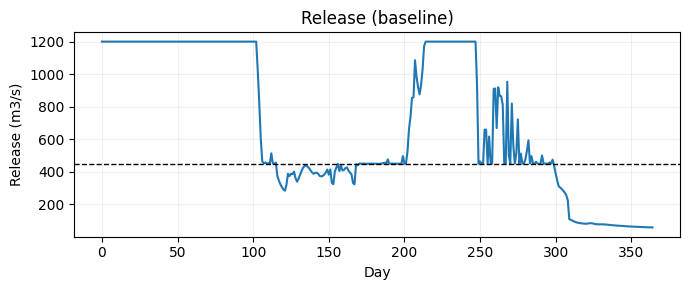

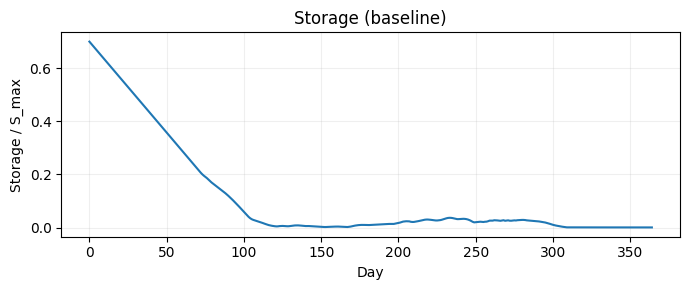

In [11]:
lam = 0.5
gamma = 1
start_index = 365*3

base7 = simulate_mpc_one_year(
    start_index=start_index,
    N=7,
    lam=lam,
    gamma=gamma,
    forecast_mode="clim",
    q_clim=q_clim,
    terminal_mode="zero",
    maxiter=60,
)

print("Baseline (climatology, N=7, terminal=0)")
print("  mean_J:", base7["mean_J"])
print("  mean_hp1:", base7["mean_hp1"])
print("  mean_food:", base7["mean_food"])

plt.figure(figsize=(7,3))
plt.plot(base7["release"])
plt.axhline(D, linestyle="--", linewidth=1, color="k", label="Demand D")
plt.xlabel("Day")
plt.ylabel("Release (m3/s)")
plt.title("Release (baseline)")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,3))
plt.plot(base7["storage"][:-1] / S_max)
plt.xlabel("Day")
plt.ylabel("Storage / S_max")
plt.title("Storage (baseline)")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## 4) Change lead time: N = 30 (still climatology, terminal = 0)

Lead time comparison (climatology, terminal=0)
  N=7  mean_J: 11542.618834312132
  N=30 mean_J: 2536.7788664488266


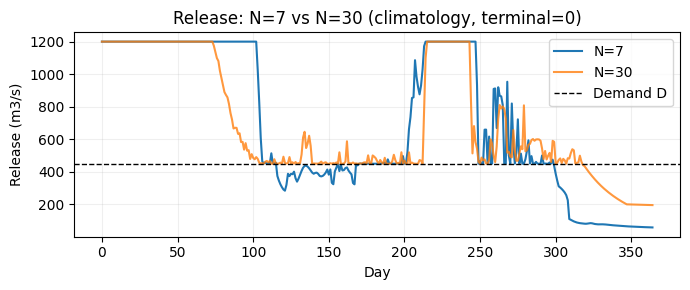

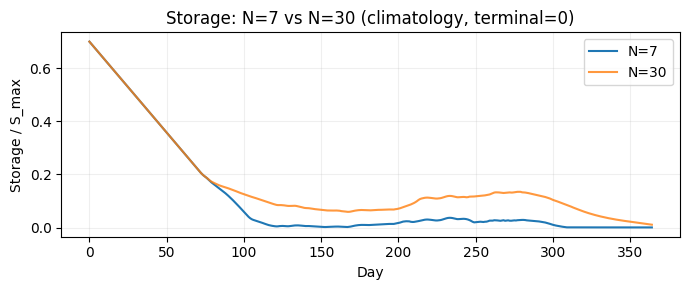

In [12]:
lead30 = simulate_mpc_one_year(
    start_index=start_index,
    N=30,
    lam=lam,
    gamma=gamma,
    forecast_mode="clim",
    q_clim=q_clim,
    terminal_mode="zero",
    maxiter=10,   # keep solves lighter for N=30
)

print("Lead time comparison (climatology, terminal=0)")
print("  N=7  mean_J:", base7["mean_J"])
print("  N=30 mean_J:", lead30["mean_J"])

plt.figure(figsize=(7,3))
plt.plot(base7["release"], label="N=7")
plt.plot(lead30["release"], label="N=30", alpha=0.8)
plt.axhline(D, linestyle="--", linewidth=1, color="k", label="Demand D")
plt.xlabel("Day")
plt.ylabel("Release (m3/s)")
plt.title("Release: N=7 vs N=30 (climatology, terminal=0)")
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,3))
plt.plot(base7["storage"][:-1] / S_max, label="N=7")
plt.plot(lead30["storage"][:-1] / S_max, label="N=30", alpha=0.8)
plt.xlabel("Day")
plt.ylabel("Storage / S_max")
plt.title("Storage: N=7 vs N=30 (climatology, terminal=0)")
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## 5) Now introduce terminal penalty from SDP: terminal = H(s) (use N = 7)

Terminal penalty comparison (climatology, N=7)
  terminal=0    mean_J: 11542.618834312132
  terminal=H(s) mean_J: 21533.328419521054


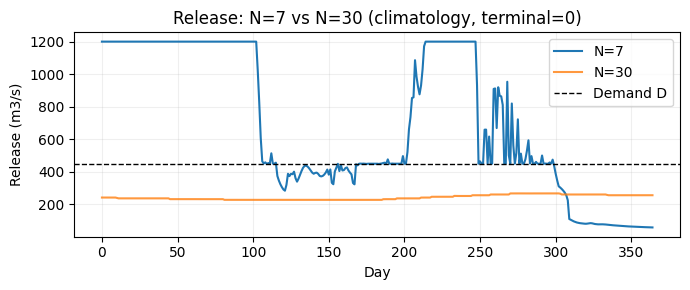

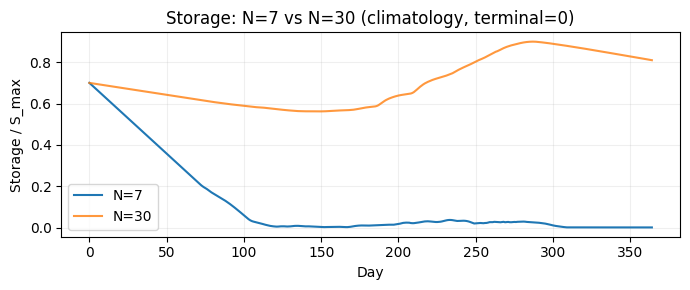

In [14]:
# H(s) from SDP lab for lambda = 0.5 (length 26)
H_sdp = np.array([
  7966244.291,    5525565.8161,   3355335.8577,   1299234.2717,
  -677833.0727,  -2602355.198,   -4469131.6066,  -6282573.2271,
  -8051023.9795, -9783947.4868, -11478807.4395, -13131202.7229,
 -14741855.6602, -16314404.3209, -17853958.8486, -19366507.2056,
 -20850672.6357, -22301754.6046, -23718309.7287, -25101081.1875,
 -26451865.9323, -27772132.2387, -29060598.7587, -30304877.5241,
 -31449605.7379, -32345327.5203], dtype=float)

# Storage grid used to interpolate H(s) (consistent with n_s=26 in SDP output)
s_grid_sdp = np.linspace(0.0, S_max, len(H_sdp))

hsdp7 = simulate_mpc_one_year(
    start_index=start_index,
    N=7,
    lam=lam,
    gamma=gamma,
    forecast_mode="clim",
    q_clim=q_clim,
    terminal_mode="Hsdp",
    H_sdp=H_sdp,
    s_grid_sdp=s_grid_sdp,
    maxiter=60,
)

print("Terminal penalty comparison (climatology, N=7)")
print("  terminal=0    mean_J:", base7["mean_J"])
print("  terminal=H(s) mean_J:", hsdp7["mean_J"])

plt.figure(figsize=(7,3))
plt.plot(base7["release"], label="N=7")
plt.plot(hsdp7["release"], label="N=30", alpha=0.8)
plt.axhline(D, linestyle="--", linewidth=1, color="k", label="Demand D")
plt.xlabel("Day")
plt.ylabel("Release (m3/s)")
plt.title("Release: N=7 vs N=30 (climatology, terminal=0)")
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,3))
plt.plot(base7["storage"][:-1] / S_max, label="N=7")
plt.plot(hsdp7["storage"][:-1] / S_max, label="N=30", alpha=0.8)
plt.xlabel("Day")
plt.ylabel("Storage / S_max")
plt.title("Storage: N=7 vs N=30 (climatology, terminal=0)")
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## 6) Better forecasts: perfect forecast benchmark (deterministic)

Forecast skill comparison (mean_J over 1 year)
  climatology  N=7  terminal=H(s): 21533.328419521054
  perfect      N=7  terminal=H(s): 18741.009242346772


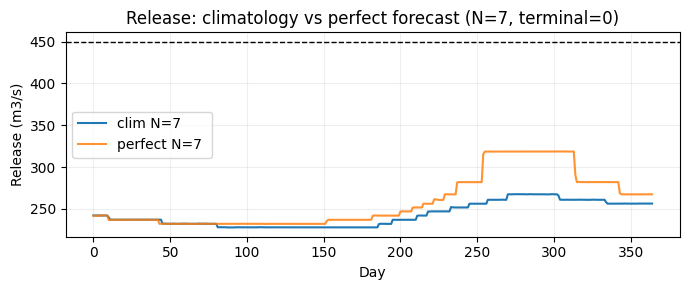

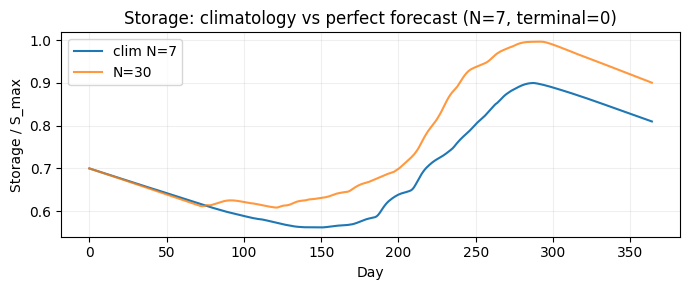

In [16]:
# Perfect forecast versions of the same experiments

hsdp7_perf = simulate_mpc_one_year(
    start_index=start_index,
    N=7,
    lam=lam,
    gamma=gamma,
    forecast_mode="perfect",
    q_clim=q_clim,
    terminal_mode="Hsdp",
    H_sdp=H_sdp,
    s_grid_sdp=s_grid_sdp,
    maxiter=60,
)

print("Forecast skill comparison (mean_J over 1 year)")
print("  climatology  N=7  terminal=H(s):", hsdp7["mean_J"])
print("  perfect      N=7  terminal=H(s):", hsdp7_perf["mean_J"])

plt.figure(figsize=(7,3))
plt.plot(hsdp7["release"], label="clim N=7")
plt.plot(hsdp7_perf["release"], label="perfect N=7 ", alpha=0.85)
plt.axhline(D, linestyle="--", linewidth=1, color="k")
plt.xlabel("Day")
plt.ylabel("Release (m3/s)")
plt.title("Release: climatology vs perfect forecast (N=7, terminal=0)")
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


plt.figure(figsize=(7,3))
plt.plot(hsdp7["storage"][:-1] / S_max, label="clim N=7")
plt.plot(hsdp7_perf["storage"][:-1] / S_max, label="perf=30", alpha=0.8)
plt.xlabel("Day")
plt.ylabel("Storage / S_max")
plt.title("Storage: climatology vs perfect forecast (N=7, terminal=0)")
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()